In [1]:
pip install "datasets<4.0.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from datasets import load_dataset

# Load the restaurant subset
dataset = load_dataset("alexcadillon/SemEval2014Task4", "restaurants")

# Explore
print(dataset)

DatasetDict({
    trial: Dataset({
        features: ['sentenceId', 'text', 'aspectTerms', 'aspectCategories'],
        num_rows: 100
    })
    train: Dataset({
        features: ['sentenceId', 'text', 'aspectTerms', 'aspectCategories'],
        num_rows: 3041
    })
    test: Dataset({
        features: ['sentenceId', 'text', 'aspectTerms', 'aspectCategories'],
        num_rows: 800
    })
})


In [2]:
dataset['train'][:2]

{'sentenceId': ['3121', '2777'],
 'text': ['But the staff was so horrible to us.',
  "To be completely fair, the only redeeming factor was the food, which was above average, but couldn't make up for all the other deficiencies of Teodora."],
 'aspectTerms': [[{'term': 'staff',
    'polarity': 'negative',
    'from': '8',
    'to': '13'}],
  [{'term': 'food', 'polarity': 'positive', 'from': '57', 'to': '61'}]],
 'aspectCategories': [[{'category': 'service', 'polarity': 'negative'}],
  [{'category': 'food', 'polarity': 'positive'},
   {'category': 'anecdotes/miscellaneous', 'polarity': 'negative'}]]}

In [3]:
# all different category available values
list({dic['category'] for sample in dataset['train']['aspectCategories'] for dic in sample})

['price', 'service', 'food', 'anecdotes/miscellaneous', 'ambience']

In [4]:
# all different aspect_term available values
len(list({dic['term'] for sample in dataset['train']['aspectTerms'] for dic in sample}))

1288

We see that the number of terms is very large and training a model working with aspect_terms can be difficult so we train the model on aspect_categories.

In [5]:
type(dataset['train'])

datasets.arrow_dataset.Dataset

In [6]:
import pandas as pd

def extract_sentence_category(df):
    rows = []

    for _, row in df.iterrows():
        sentence = row['text']
        categories = row['aspectCategories']

        if categories:  # skip empty ones
            for cat in categories:
                rows.append({
                    'sentence': sentence,
                    'category': cat['category'],
                    'polarity': cat['polarity']
                })

    return pd.DataFrame(rows)

In [7]:
train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

flat_train_df = extract_sentence_category(train_df)
flat_test_df  = extract_sentence_category(test_df)

print("Train size:", flat_train_df.shape)
print("Test size:", flat_test_df.shape)

flat_train_df.head()

Train size: (3713, 3)
Test size: (1025, 3)


,sentence,category,polarity
0,But the staff was so horrible to us.,service,negative
1,"To be completely fair, the only redeeming fact...",food,positive
2,"To be completely fair, the only redeeming fact...",anecdotes/miscellaneous,negative
3,"The food is uniformly exceptional, with a very...",food,positive
4,Where Gabriela personaly greets you and recomm...,service,positive


In [8]:
print(flat_train_df['polarity'].unique())
print(flat_train_df[flat_train_df['polarity'] == 'conflict']['category'])
list(flat_train_df[flat_train_df['polarity'] == 'conflict']['sentence'])[:5]

['negative' 'positive' 'conflict' 'neutral']
15                      service
70                         food
95      anecdotes/miscellaneous
102                        food
106                     service
                 ...           
3577    anecdotes/miscellaneous
3579    anecdotes/miscellaneous
3629                    service
3635                   ambience
3654                       food
Name: category, Length: 195, dtype: object


['It took half an hour to get our check, which was perfect since we could sit, have drinks and talk!',
 'The food was delicious but do not come here on a empty stomach.',
 'Go here for a romantic dinner but not for an all out wow dining experience.',
 'The menu is limited but almost all of the dishes are excellent.',
 "The service varys from day to day- sometimes they're very nice, and sometimes not."]

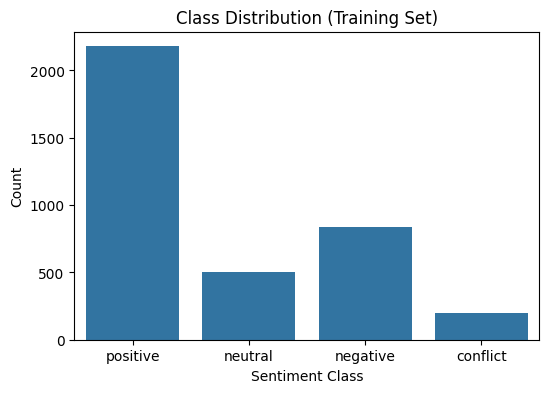

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='polarity', data=flat_train_df, order=['positive','neutral','negative','conflict'])
plt.title("Class Distribution (Training Set)")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.show()

In [10]:
flat_train_df['split'] = 'train'
flat_test_df['split'] = 'test'

combined_df = pd.concat([flat_train_df, flat_test_df])
combined_df.head()

,sentence,category,polarity,split
0,But the staff was so horrible to us.,service,negative,train
1,"To be completely fair, the only redeeming fact...",food,positive,train
2,"To be completely fair, the only redeeming fact...",anecdotes/miscellaneous,negative,train
3,"The food is uniformly exceptional, with a very...",food,positive,train
4,Where Gabriela personaly greets you and recomm...,service,positive,train


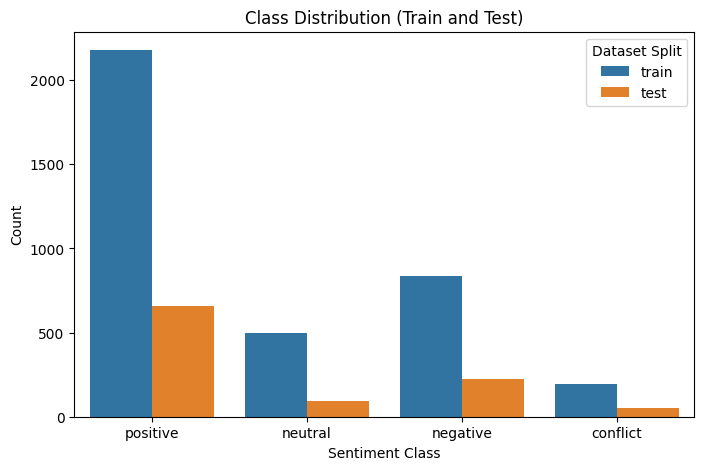

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))

sns.countplot(
    data=combined_df,
    x='polarity',
    hue='split',
    order=['positive','neutral','negative','conflict']
)

plt.title("Class Distribution (Train and Test)")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.legend(title="Dataset Split")
plt.show()

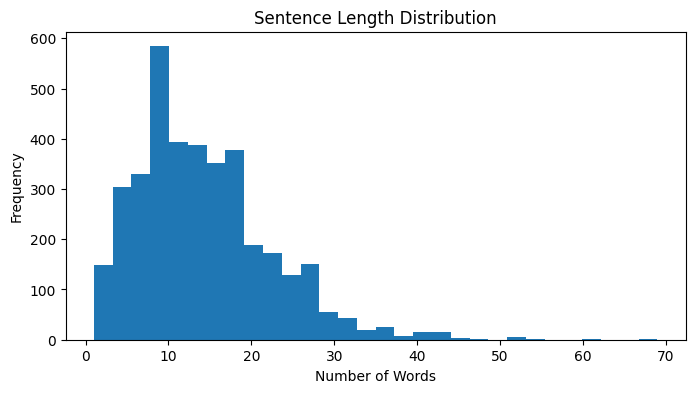

In [12]:
flat_train_df['sentence_length'] = flat_train_df['sentence'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,4))
plt.hist(flat_train_df['sentence_length'], bins=30)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [14]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


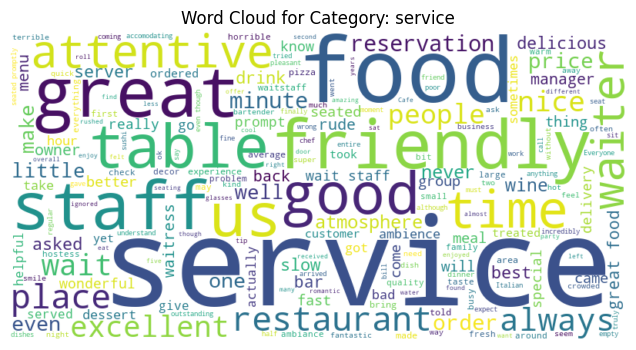

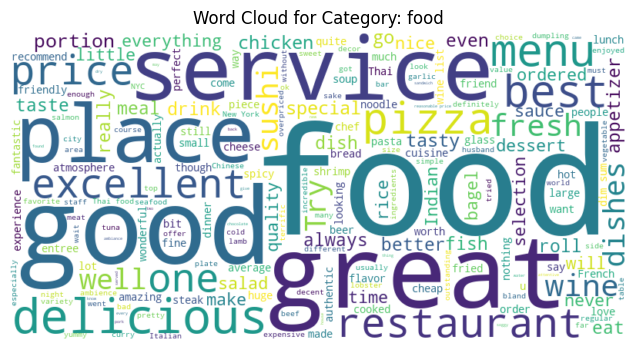

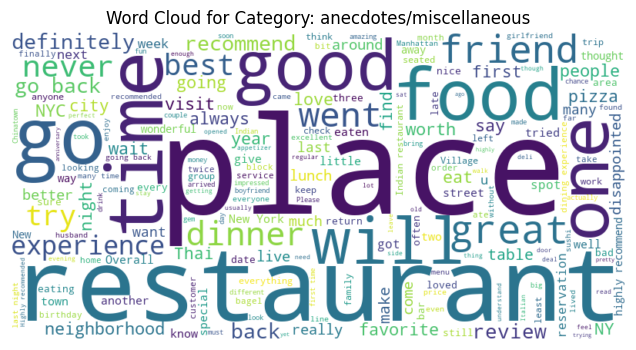

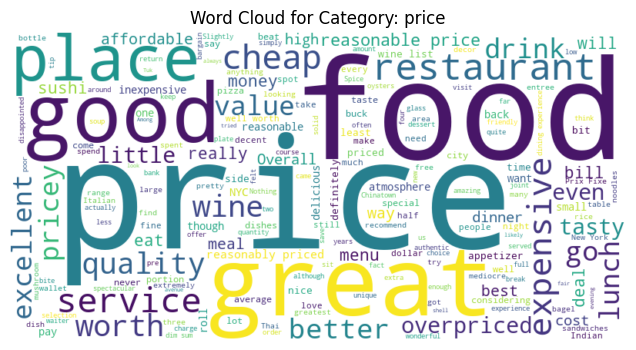

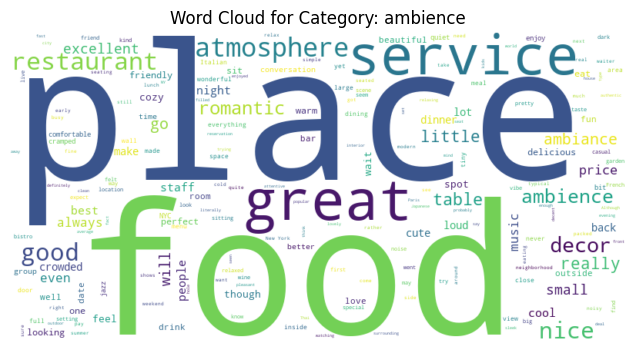

In [13]:
from wordcloud import WordCloud

categories = flat_train_df['category'].unique()

for cat in categories:
    text = " ".join(flat_train_df[flat_train_df['category'] == cat]['sentence'])

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Category: {cat}")
    plt.show()

# فاز دوم: طراحی و پیاده‌سازی مدل (ABSA)

در این بخش معماری مدل مبتنی بر ترنسفورمر (BERT/RoBERTa) برای شناسایی قطبیت هر جنبه پیاده‌سازی می‌شود.
- **ورودی مدل**: ترکیب جمله و کلمه جنبه (aspect/category) به صورت ورودی قابل قبول برای مدل
- **مدل**: مدل زبان پیش‌آموزش‌دیده + لایه کلاسifier برای ۳ کلاس (مثبت، منفی، خنثی)
- **آموزش**: آموزش روی داده‌های آماده‌شده با گزارش هایپرپارامترها و نمودارهای loss و accuracy

In [14]:
# آماده‌سازی داده برای کلاس‌بندی ۳ کلاسه (مثبت، منفی، خنثی)
# حذف نمونه‌های با برچسب conflict برای کلاس‌بندی ۳ کلاسه

LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {0: 'negative', 1: 'neutral', 2: 'positive'}
NUM_LABELS = 3

train_phase2 = flat_train_df[flat_train_df['polarity'].isin(LABEL2ID.keys())].copy()
test_phase2  = flat_test_df[flat_test_df['polarity'].isin(LABEL2ID.keys())].copy()

train_phase2['label'] = train_phase2['polarity'].map(LABEL2ID)
test_phase2['label']  = test_phase2['polarity'].map(LABEL2ID)

print("تعداد کلاس‌ها:", NUM_LABELS)
print("تعداد نمونه آموزش (بدون conflict):", len(train_phase2))
print("تعداد نمونه تست (بدون conflict):", len(test_phase2))
print("توزیع برچسب در آموزش:")
print(train_phase2['polarity'].value_counts())

تعداد کلاس‌ها: 3
تعداد نمونه آموزش (بدون conflict): 3518
تعداد نمونه تست (بدون conflict): 973
توزیع برچسب در آموزش:
polarity
positive    2179
negative     839
neutral      500
Name: count, dtype: int64


In [16]:
# نصب کتابخانه‌های مورد نیاز فاز ۲ (یک بار اجرا کنید)
# pip install transformers torch scikit-learn
# در صورت نصب بودن، این سلول را رد کنید.
try:
    import transformers
    import torch
    print("transformers و torch از قبل نصب هستند.")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "transformers", "torch", "scikit-learn"], check=True)

transformers و torch از قبل نصب هستند.


In [15]:
# ورودی مدل (۱۰ نمره): ترکیب جمله و جنبه (aspect/category) برای ورودی مدل
# پیاده‌سازی کلاس Dataset برای ترکیب sentence و category به فرمت قابل قبول BERT/RoBERTa
# فرمت ورودی: [CLS] sentence [SEP] aspect [SEP]

import torch
from torch.utils.data import Dataset

class ABSADataset(Dataset):
    """
    Dataset برای ABSA: هر نمونه = یک جمله + یک جنبه (category) با برچسب قطبیت.
    ورودی توکنایزر: جمله و جنبه به صورت دو سگمنت (sentence + aspect) برای مدل.
    """
    def __init__(self, sentences, aspects, labels, tokenizer, max_length=128):
        self.sentences = sentences
        self.aspects = aspects
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sentence = str(self.sentences[idx])
        aspect = str(self.aspects[idx])
        label = self.labels[idx]

        # ترکیب جمله و جنبه برای مدل: معمولاً به صورت "sentence [SEP] aspect"
        encoded = self.tokenizer(
            sentence,
            aspect,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt',
            return_attention_mask=True
        )

        return {
            'input_ids': encoded['input_ids'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [16]:
# مدل زبان پیش‌آموزش‌دیده و لایه کلاسifier ۳ کلاسه (۴۰ نمره)
# استفاده از BERT-Base یا RoBERTa؛ لایه آخر برای کلاس‌بندی ۳ کلاسه تغییر داده می‌شود.

from transformers import AutoModel, AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "bert-base-uncased"  # یا "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
print(f"مدل بارگذاری شد: {MODEL_NAME}")
print(f"تعداد کلاس‌های خروجی: {NUM_LABELS}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


مدل بارگذاری شد: bert-base-uncased
تعداد کلاس‌های خروجی: 3


In [17]:
# ایجاد Dataset و DataLoader با اعتبارسنجی (validation split)

from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split

MAX_LENGTH = 128
BATCH_SIZE = 16
VAL_RATIO = 0.15
RANDOM_STATE = 42

# تقسیم آموزش به train/validation
train_sents, val_sents, train_asps, val_asps, train_lbl, val_lbl = train_test_split(
    train_phase2['sentence'].tolist(),
    train_phase2['category'].tolist(),
    train_phase2['label'].tolist(),
    test_size=VAL_RATIO,
    random_state=RANDOM_STATE,
    stratify=train_phase2['label']
)

train_dataset = ABSADataset(train_sents, train_asps, train_lbl, tokenizer, max_length=MAX_LENGTH)
val_dataset   = ABSADataset(val_sents, val_asps, val_lbl, tokenizer, max_length=MAX_LENGTH)
test_dataset  = ABSADataset(
    test_phase2['sentence'].tolist(),
    test_phase2['category'].tolist(),
    test_phase2['label'].tolist(),
    tokenizer,
    max_length=MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=RandomSampler(train_dataset), num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=SequentialSampler(val_dataset), num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, sampler=SequentialSampler(test_dataset), num_workers=0)

print("تعداد batch آموزش:", len(train_loader))
print("تعداد batch اعتبارسنجی:", len(val_loader))

تعداد batch آموزش: 187
تعداد batch اعتبارسنجی: 33


In [18]:
# تنظیمات و هایپرپارامترها (۵ نمره) — گزارش دقیق

EPOCHS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = base_model.to(device)

from torch.optim import AdamW
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# گزارش هایپرپارامترها
print("=== گزارش هایپرپارامترها و تنظیمات ===")
print("Model:", MODEL_NAME)
print("Batch Size:", BATCH_SIZE)
print("Max Length:", MAX_LENGTH)
print("Epochs:", EPOCHS)
print("Learning Rate:", LEARNING_RATE)
print("Weight Decay:", WEIGHT_DECAY)
print("Validation Ratio:", VAL_RATIO)
print("Random State:", RANDOM_STATE)
print("Device:", device)

=== گزارش هایپرپارامترها و تنظیمات ===
Model: bert-base-uncased
Batch Size: 16
Max Length: 128
Epochs: 4
Learning Rate: 2e-05
Weight Decay: 0.01
Validation Ratio: 0.15
Random State: 42
Device: cpu


In [19]:
# حلقه آموزش و ذخیره loss و accuracy برای هر اپاک (۵ نمره — نمودارها)

from tqdm import tqdm

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

def compute_accuracy(preds, labels):
    return (preds == labels).float().mean().item()

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    epoch_train_correct = 0
    epoch_train_total = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        epoch_train_correct += (preds == labels).sum().item()
        epoch_train_total += labels.size(0)

    train_loss = epoch_train_loss / len(train_loader)
    train_acc = epoch_train_correct / epoch_train_total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # اعتبارسنجی
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss_sum += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / len(val_loader)
    val_acc = val_correct / val_total
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1} — Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/4: 100%|██████████| 187/187 [22:52<00:00,  7.34s/it]


Epoch 1 — Train Loss: 0.6469, Train Acc: 0.7395 | Val Loss: 0.5116, Val Acc: 0.8106


Epoch 2/4: 100%|██████████| 187/187 [24:51<00:00,  7.98s/it]


Epoch 2 — Train Loss: 0.3864, Train Acc: 0.8569 | Val Loss: 0.5453, Val Acc: 0.7879


Epoch 3/4: 100%|██████████| 187/187 [26:16<00:00,  8.43s/it] 


Epoch 3 — Train Loss: 0.2425, Train Acc: 0.9147 | Val Loss: 0.5365, Val Acc: 0.8068


Epoch 4/4: 100%|██████████| 187/187 [12:45<00:00,  4.09s/it]


Epoch 4 — Train Loss: 0.1431, Train Acc: 0.9482 | Val Loss: 0.6841, Val Acc: 0.7992


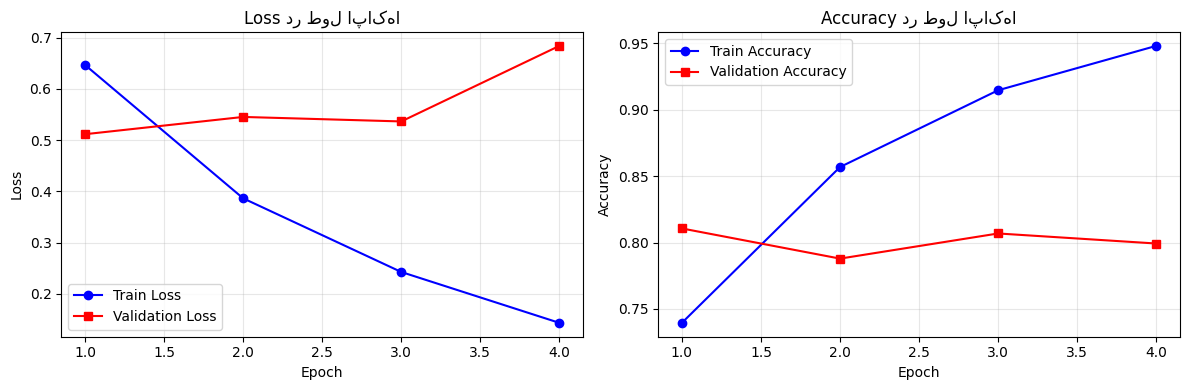

In [20]:
# نمودار تغییرات Loss و Accuracy در طول اپاک‌ها (۵ نمره)

import matplotlib.pyplot as plt
import numpy as np

epochs_range = np.arange(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=6)
ax1.plot(epochs_range, history['val_loss'], 'r-s', label='Validation Loss', markersize=6)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss در طول اپاک‌ها')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy', markersize=6)
ax2.plot(epochs_range, history['val_acc'], 'r-s', label='Validation Accuracy', markersize=6)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy در طول اپاک‌ها')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# ارزیابی نهایی روی داده تست

model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_accuracy = test_correct / test_total
print(f"دقت نهایی روی داده تست: {test_accuracy:.4f} ({test_correct}/{test_total})")

دقت نهایی روی داده تست: 0.8941 (870/973)
